# Hierarchical VAE for MNIST

Model structure
* Hierarchical generative model
$$p(x,Z) = p(x|z_1) \prod_l p_t(z_{t_l}|z_{t_{l-1}}) p_0(z_0) $$
* Simple Gaussian prior
$$p_0(z_0) = N(0,I)$$
* The conditional (transition)
$$p_t(z_t|z_s)= N(\mu_\theta(z_s,t),\mathrm{diag}(\sigma^2_\theta(z_s,t)))$$
uses parameter sharing, that is $\mu_\theta(z_s,t)$ and $\sigma_\theta(z_s,t)$ are implemented with a neural network that takes $t$ as input so that the mappings learned depends on the layer index.
* Variational is chosen to have the same structure as the generative hierarchy  
$$q(Z|x)=\prod_l q_t(z_{t_l}|z_{t_{l-1}},x) q_0(z_0|x)$$
* The variational conditional
$$q_t(z_{t_l}|z_{t_{l-1}},x)=N(\mu_\phi(z_s,t),\mathrm{diag}(\sigma^2_\phi(z_s,t)))$$
is implemented with a neural network just like the generative model.
* Finally the same network is reused for the $z_0$ term:
$$q_0(z_0|x)=  N(\mu_\phi(0,0),\mathrm{diag}(\sigma^2_\phi(0,0)))$$

The network structure, use of warm-up and dynamic binarized MNIST are all inspired by the [ladder VAE](https://arxiv.org/abs/1602.02282) paper.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, kl_divergence, Bernoulli
import numpy as np
import matplotlib.pyplot as plt

#print(torch.backends.mps.is_available())  # True if MPS is usable
#print(torch.backends.mps.is_built())      # True if MPS support is built into PyTorch
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device =torch.device("cpu")

def kl_warmup_factor(epoch, warmup_epochs=50, schedule="linear"):
    """
    Returns a scaling factor in [0,1] for KL terms during warm-up.

    schedule:
      - "linear": linearly increases from 0 to 1 over warmup_epochs
      - "exp": exponential growth
      - "sigmoid": smooth logistic curve
    """
    if epoch >= warmup_epochs:
        return 1.0
    progress = epoch / warmup_epochs
    if schedule == "linear":
        return progress
    elif schedule == "exp":
        return min(1.0, np.exp(5 * (progress - 1)))
    elif schedule == "sigmoid":
        return 1 / (1 + np.exp(-12 * (progress - 0.5)))
    else:
        raise ValueError(f"Unknown schedule: {schedule}")

# MNIST loader

MNIST comes a greyscale. We model it as Bernoulli. To avoid overfitting we train in dynamic binarization: We use greyscale value as probability of pixel value (black/white) and draw a new random binary image each time the image is used. See demonstration below.

In [7]:
import torch
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, transforms
from pathlib import Path

# Cache dir
DATA_DIR = Path.home() / ".cache" / "torchvision"
DATA_DIR.mkdir(parents=True, exist_ok=True)

class BinarizeWrapper(Dataset):
    """
    Wraps any dataset that returns (image, label) where image is a tensor in [0,1].
    Allows:
      - dynamic stochastic binarization (train)
      - fixed (non-dynamic) behavior (val/test)
    """
    def __init__(self, base_dataset, binarize: bool, dynamic: bool, flatten: bool):
        self.base = base_dataset
        self.binarize = binarize
        self.dynamic = dynamic
        self.flatten = flatten

        # If not dynamic but binarize=True, we "freeze" a binarized copy once
        # (good for val/test so they are stable).
        self._frozen = None
        if self.binarize and not self.dynamic:
            self._frozen = []
            for i in range(len(self.base)):
                x, y = self.base[i]
                x_bin = torch.bernoulli(x)  # one-time binarization
                self._frozen.append((x_bin, y))

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        if self._frozen is not None:
            x, y = self._frozen[idx]
        else:
            x, y = self.base[idx]
            if self.binarize:
                if self.dynamic:
                    x = torch.bernoulli(x)   # resample each access
                else:
                    # (shouldn't get here because non-dynamic uses _frozen)
                    x = (x > 0.5).float()

        if self.flatten:
            x = x.view(-1)
        return x, y


def load_mnist_textbook_split(
    batch_size=128,
    val_size=5000,
    binarize_train=True,
    dynamic_train=True,
    binarize_val=True,
    dynamic_val=False,
    binarize_test=True,
    dynamic_test=False,
    flatten=True,
    num_workers=0,
    seed=0,
):
    """
    Textbook split:
      - train/val split from the *training* MNIST set
      - test set is official MNIST test
    Dynamic binarization:
      - usually only on train (dynamic_train=True)
      - val/test kept fixed (dynamic_val/test=False) to make metrics stable
    """
    base_transform = transforms.ToTensor()

    full_train = datasets.MNIST(
        root=DATA_DIR, train=True, download=True, transform=base_transform
    )
    test_base = datasets.MNIST(
        root=DATA_DIR, train=False, download=True, transform=base_transform
    )

    # Split training set into train/val
    n_train = len(full_train) - val_size
    g = torch.Generator().manual_seed(seed)
    train_subset, val_subset = random_split(full_train, [n_train, val_size], generator=g)

    # Wrap subsets with desired binarization behavior
    train_ds = BinarizeWrapper(train_subset, binarize=binarize_train, dynamic=dynamic_train, flatten=flatten)
    val_ds   = BinarizeWrapper(val_subset,   binarize=binarize_val,   dynamic=dynamic_val,   flatten=flatten)
    test_ds  = BinarizeWrapper(test_base,    binarize=binarize_test,  dynamic=dynamic_test,  flatten=flatten)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                              num_workers=num_workers, pin_memory=(torch.cuda.is_available()))
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False,
                              num_workers=num_workers, pin_memory=(torch.cuda.is_available()))
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False,
                              num_workers=num_workers, pin_memory=(torch.cuda.is_available()))

    return train_loader, val_loader, test_loader


In [8]:
train_loader, val_loader, test_loader = load_mnist_textbook_split(
    batch_size=256,
    val_size=5000,
    binarize_train=True, dynamic_train=True,
    binarize_val=True,   dynamic_val=False,
    binarize_test=True,  dynamic_test=False,
    flatten=True,
    seed=0
)

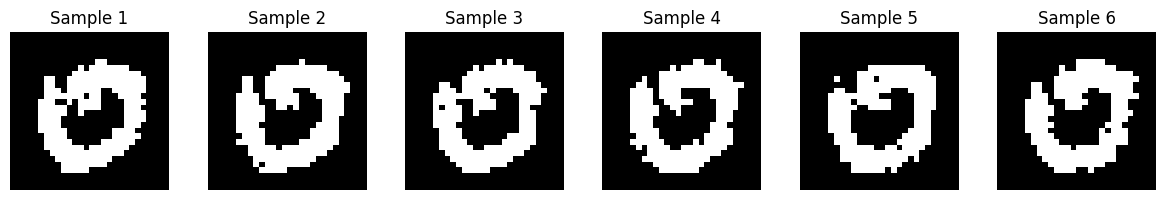

In [9]:
# Validating that dynamic binarization works

dataset =  train_loader.dataset
idx = 42  # Change if you want to visualize a different sample

samples = [dataset[idx][0] for _ in range(6)]  # Sample same image 6 times

# Plot the different binarizations
fig, axs = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axs[i].imshow(samples[i].view(28, 28), cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f"Sample {i+1}")
plt.tight_layout()
plt.show()

# Define models

In [10]:
class MarkovTransition(nn.Module): # p_t(z_t|z_s)
    def __init__(self, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, 2 * latent_dim)
        )
        self.var_offset = 1e-4

    def forward(self, x_in):
        mu, log_var = self.net(x_in).chunk(2, dim=-1)
        var = log_var.exp() + self.var_offset
        return mu, torch.sqrt(var)

class Decoder(nn.Module): # p(x|z) logits
    def __init__(self, latent_dim=64, hidden_dim=512, output_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, output_dim)
        )
        self.latent_dim = latent_dim
        self.logit_clamp=11.51 # logit(1e-5)

    def forward(self, z):
        logits = self.net(z)
        logits = logits.clamp(min=-self.logit_clamp, max=self.logit_clamp)
        return logits  # [B, 784]

class MarkovEncoder(nn.Module): # q_t(z_t|z_s)
    def __init__(self, input_dim=784, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, 2 * latent_dim)
        )
        self.var_offset = 1e-4

    def forward(self, x):
        mu, log_var = self.net(x).chunk(2, dim=-1)
        var = log_var.exp() + self.var_offset
        return mu, torch.sqrt(var)

In [21]:
class hierarchical_VAE(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=512, dropout_prob=0.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.device = device

        self.encoder = MarkovEncoder(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.transition = MarkovTransition(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    def p(self, z_prev, t):
        inp = torch.cat([z_prev, t], dim=-1)
        mu, sigma = self.transition(inp)
        return mu, sigma

    def q(self, x_flat, z_prev, t):
        inp = torch.cat([x_flat, z_prev, t], dim=-1)
        mu, sigma = self.encoder(inp)
        return mu, sigma

    def elbo(self, x, t_grid, kl_scale=1.0, return_parts=False):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        T = len(t_grid)
        T_tensor = torch.full((B, 1), float(T), device=self.device)

        kl_per_step = []

        # Prior at t=0
        t0 = t_grid[0].expand(B, 1)
        mu_q0, sigma_q0 = self.q(x_flat, torch.zeros(B, self.latent_dim, device=self.device),t0)
        q0 = Normal(mu_q0, sigma_q0)
        p0 = Normal(torch.zeros_like(mu_q0), torch.ones_like(sigma_q0))
        kl0 = kl_divergence(q0, p0).sum(-1).mean()
        kl_per_step.append(kl0.item())

        z = mu_q0 + sigma_q0 * torch.randn_like(mu_q0)
        kl_transition = 0.0

        for idx in range(1, T):
            t = t_grid[idx].expand(B, 1)

            mu_q, sigma_q = self.q(x_flat, z, t)
            mu_p, sigma_p = self.p(z, t)

            q_dist = Normal(mu_q, sigma_q)
            p_dist = Normal(mu_p, sigma_p)

            kl_t = kl_divergence(q_dist, p_dist).sum(-1).mean()
            kl_per_step.append(kl_t.item())
            kl_transition += kl_t

            z = mu_q + sigma_q * torch.randn_like(mu_q)

        logits = self.decoder(z)
        recon = -F.binary_cross_entropy_with_logits(logits, x_flat, reduction='sum') / B

        kl_total = kl0 + kl_transition
        elbo = recon - kl_scale * kl_total

        if return_parts:
            return elbo, recon.item(), kl_total.item(), kl_per_step
        else:
            return elbo

    @torch.no_grad()
    def generate_samples(self, num_samples=64, t_grid=range(1, 2)):
        """
        Draw samples from p_t(z_t|z_{t-1}) starting from prior z_0 ~ N(0,I).
        """
        z = torch.randn(num_samples, self.latent_dim, device=self.device)
        T = len(t_grid)

        for idx in range(1, T):
            t = t_grid[idx].expand(num_samples, 1)
            mu_p, sigma_p = self.p(z, t)
            z = mu_p + sigma_p * torch.randn_like(mu_p)

        logits = self.decoder(z)
        probs = torch.sigmoid(logits)
        x_samples = torch.bernoulli(probs)
        return x_samples.view(-1, 1, 28, 28)

    @torch.no_grad()
    def evaluate_elbo(self, data_loader, t_grid, return_parts=False):
        """
        Evaluate mean ELBO (and optionally recon, KL total, and KL curves) over a dataset.
        """
        self.eval()
        total_elbo = 0.0
        total_recon = 0.0
        total_kl = 0.0
        all_kl_curves = []

        n = 0
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(self.device)
            B = x_batch.shape[0]

            if return_parts:
                elbo_batch, recon_batch, kl_total_batch, kl_curve = self.elbo(
                    x_batch, t_grid, return_parts=True
                )
                total_recon += recon_batch * B
                total_kl += kl_total_batch * B
                all_kl_curves.append(kl_curve)
            else:
                elbo_batch = self.elbo(x_batch, t_grid)

            total_elbo += elbo_batch.item() * B
            n += B

        mean_elbo = total_elbo / n
        if return_parts:
            mean_recon = total_recon / n
            mean_kl = total_kl / n
            mean_kl_curve = torch.tensor(all_kl_curves).mean(dim=0).tolist()
            return mean_elbo, mean_recon, mean_kl, mean_kl_curve
        else:
            return mean_elbo

    def iwae(self, x, t_grid, K=50):
        """
        Compute IWAE bound for a batch of data y with K importance samples.
        Markov q(z_t|z_{t-1}, x).
        Args:
            x: [B, …] (original data, e.g. images)
            t_grid: [T] tensor of timepoints in [0,1]
            K: number of importance samples
        """
        B = x.shape[0]
        x_flat = x.view(B, -1)  # flatten

        T = len(t_grid)

        # Repeat y for K importance samples
        x_flat = x_flat.unsqueeze(1).repeat(1, K, 1).view(B * K, -1)
        T_tensor = torch.full((B * K, 1), float(T), device=self.device)

        # ---- Step t=0 ----
        t0 = t_grid[0].expand(B * K, 1)
        mu_q0, sigma_q0 = self.q(
            x_flat, torch.zeros(B * K, self.latent_dim, device=self.device),
            t0
        )
        eps0 = torch.randn_like(mu_q0)
        z = mu_q0 + sigma_q0 * eps0

        q_logprob = Normal(mu_q0, sigma_q0).log_prob(z).sum(-1)
        p_logprob = Normal(torch.zeros_like(mu_q0), torch.ones_like(sigma_q0)).log_prob(z).sum(-1)

        log_w = p_logprob - q_logprob  # [B*K]

        # ---- Steps t=1,...,T-1 ----
        for idx in range(1, T):
            t = t_grid[idx].expand(B * K, 1)

            mu_q, sigma_q = self.q(x_flat, z, t)
            eps = torch.randn_like(mu_q)
            z_new = mu_q + sigma_q * eps

            mu_p, sigma_p = self.p(z, t) # , T_tensor)

            q_logprob = Normal(mu_q, sigma_q).log_prob(z_new).sum(-1)
            p_logprob = Normal(mu_p, sigma_p).log_prob(z_new).sum(-1)

            log_w += p_logprob - q_logprob
            z = z_new

        # ---- Final decoding ----
        #z_T = torch.cat([z, T_tensor], dim=-1)
        logits = self.decoder(z) #z_T)
        recon_logprob = -F.binary_cross_entropy_with_logits(
            logits, x_flat, reduction='none'
        ).sum(-1)

        log_w += recon_logprob

        # ---- IWAE bound ----
        log_w = log_w.view(B, K)
        iwae_bound = torch.logsumexp(log_w, dim=1) - np.log(K)
        return iwae_bound.mean()

    @torch.no_grad()
    def evaluate_iwae_bound(self, data_loader, t_grid, K=50):
        """
        Evaluate mean IWAE bound over a dataset.
        """
        self.eval()
        total_iwae = 0.0
        n = 0
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(self.device)
            B = x_batch.shape[0]
            iwae_batch = self.iwae(x_batch, t_grid, K=K)
            total_iwae += iwae_batch.item() * B
            n += B
        return total_iwae / n



# Training loop

lr=0.00040 n_epochs=10 warmup_epochs=5
Epoch   0 | ELBO: -153.811 | Validation ELBO: -402.335
Epoch   1 | ELBO: -95.063 | Validation ELBO: -155.265
Epoch   2 | ELBO: -98.769 | Validation ELBO: -133.193
Epoch   3 | ELBO: -104.567 | Validation ELBO: -122.129
Epoch   4 | ELBO: -108.619 | Validation ELBO: -115.093
Epoch   5 | ELBO: -112.201 | Validation ELBO: -111.438
Epoch   6 | ELBO: -109.552 | Validation ELBO: -109.335
Epoch   7 | ELBO: -107.621 | Validation ELBO: -107.626
Epoch   8 | ELBO: -106.214 | Validation ELBO: -106.461
Epoch   9 | ELBO: -105.152 | Validation ELBO: -105.392


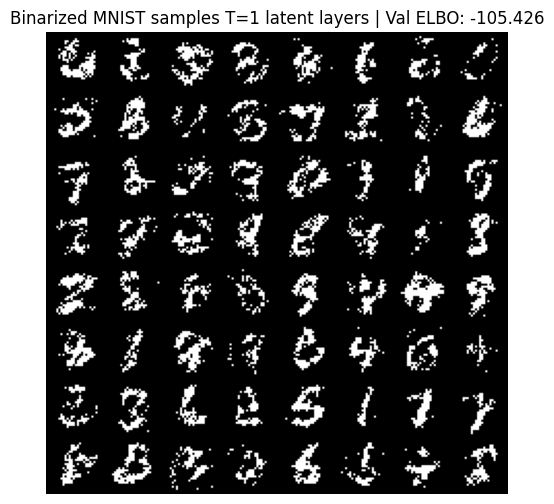

In [23]:
import matplotlib.pyplot as plt

model = hierarchical_VAE(latent_dim=100, hidden_dim=784).to(device)

T = 1 # number of latent layers
T_grid = torch.linspace(0, 1, T)

lr = 4e-4
n_epochs = 10
warmup_epochs = 5

print(f"lr={lr:.5f} n_epochs={n_epochs} warmup_epochs={warmup_epochs}")

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

for epoch in range(n_epochs):
    scale = kl_warmup_factor(epoch, warmup_epochs=warmup_epochs, schedule="linear")
    epoch_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        loss = -model.elbo(x_batch, T_grid, kl_scale=scale)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    val_elbo = model.evaluate_elbo(val_loader, T_grid)
    print(f"Epoch {epoch:3d} | ELBO: {-epoch_loss/len(train_loader):.3f} | Validation ELBO: {val_elbo:.3f}")

# Generate samples
val_elbo_final = model.evaluate_elbo(val_loader, T_grid)
#val_iwae_final = model.evaluate_iwae_bound(val_loader, T_grid)
samples = model.generate_samples(64, T_grid).cpu()

# Visualize
grid = torch.cat([torch.cat([samples[i * 8 + j] for j in range(8)], dim=-1) for i in range(8)], dim=-2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.squeeze(0), cmap="gray")
plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f}")
#plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f} | Val IWAE: {val_iwae_final:.3f}")
plt.axis("off")
plt.show()